In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
# data importing

In [3]:
data = pd.read_csv("C:\\Users\\anshu kumar\\Downloads\\messy_customer_sales_data.csv")

In [4]:
# data inspection
data

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,CUST10767,Robert Lewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10196,NaN,Diane Evans,M,53.0,bangalore,2023-12-31,2025-05-07,11639.0,7.0,lisadennis@example.net,5200349941,IND
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


In [5]:
# data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


In [6]:
# data descirbe
data.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


In [7]:
# data null values
data.isnull().sum()

Customer_ID           1023
Name                     0
Gender                1026
Age                    951
City                  1016
Signup_Date              0
Last_Purchase_Date    1012
Purchase_Amount       1021
Feedback_Score        1023
Email                    0
Phone_Number             0
Country                732
dtype: int64

In [8]:
# data duplicate rows shape
data[data.duplicated()].shape

(15, 12)

In [9]:
# data duplicate rows
data[data.duplicated()]

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2032,CUST2755,Casey Campbell,male,NaN,Hyderabad,2023-12-01,2024-11-04,11778.0,3.0,joseph49@example.com,3844741384,India
3191,NaN,Travis Schneider,f,51.0,NaN,2025-04-20,2025-02-28,48750.0,5.0,bianca77@example.net,7623118785,India
4312,CUST8305,Stanley Cain,FEMALE,51.0,Bangalore,2023-08-14,2024-11-01,11432.0,6.0,calderonbrenda@example.org,4889366037,India
5611,CUST6288,Jonathon Kim,male,46.0,Chennai,2023-11-22,2025-03-21,3301.0,6.0,tparker@example.com,5266662560,India
5680,CUST2695,Lisa Durham,NaN,46.0,Chennai,2021-04-18,2024-10-10,6511.0,3.0,andrew34@example.com,2235480149,India
5899,CUST8841,Amanda Hill,NaN,34.0,chennai,2022-09-11,2025-03-13,42092.0,4.0,ryanriley@example.net,3466026146,India
6070,CUST10780,Emily Smith,NaN,23.0,Kolkata,2023-12-09,2024-10-28,18027.0,5.0,perezchristopher@example.com,3032282870,India
6240,CUST9745,David Morales,NaN,56.0,NaN,2023-02-18,2024-12-14,49107.0,7.0,juliaknapp@example.com,9436163110,India
6425,CUST4631,George Villa,m,26.0,Mumbai,2022-05-21,2025-06-17,NaN,8.0,davidmarquez@example.com,8869465862,India
6498,CUST1711,Stephanie Elliott,NaN,44.0,MUMBAI,2023-05-17,2025-07-12,11349.0,9.0,nfischer@example.com,3270872546,NaN


In [10]:
data[data['Customer_ID']== 'CUST2755']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
1874,CUST2755,Casey Campbell,male,NaN,Hyderabad,2023-12-01,2024-11-04,11778.0,3.0,joseph49@example.com,3844741384,India
2032,CUST2755,Casey Campbell,male,NaN,Hyderabad,2023-12-01,2024-11-04,11778.0,3.0,joseph49@example.com,3844741384,India


In [11]:
# duplicate column
data['Customer_ID'].value_counts().head(177)

Customer_ID
CUST3374     2
CUST7749     2
CUST10800    2
CUST6588     2
CUST9062     2
            ..
CUST7333     2
CUST4492     2
CUST2872     2
CUST3501     2
CUST10780    2
Name: count, Length: 177, dtype: int64

In [12]:
data[data['Customer_ID'] == 'CUST3374']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2914,CUST3374,Timothy Wallace,m,58.0,Bangalore,2024-03-08,2025-08-21,45779.0,1.0,glenn95@example.org,9687701793,India
3047,CUST3374,Timothy Wallace,m,58.0,bangalore,2024-03-08,2025-08-21,45779.0,1.0,glenn95@example.org,9687701793,India


In [13]:
data['Age'].value_counts()

Age
66.0          197
62.0          194
43.0          188
34.0          186
64.0          185
             ... 
33.0 years      4
-10             3
39.0 years      3
32.0 years      3
56.0 years      2
Name: count, Length: 108, dtype: int64

In [14]:
for col in data.columns:
    if data[col].nunique() < 20:
        print(data[col].value_counts())
        print('-'*50)

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
--------------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
--------------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
--------------------------------------------------


# Data Cleaning

In [15]:
# remove null values
data.dropna(subset=['Customer_ID'], inplace = True)

In [16]:
data.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                   859
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [17]:
data['Age'].unique()

array(['52.0', '51.0 years', '62.0', '40.0', '41.0', nan, '18.0',
       '43.0 years', '40.0 years', '26.0', '32.0', '22.0', '59.0', '65.0',
       '61.0', '31.0', '54.0 years', '55.0', '69.0', '61.0 years', '24.0',
       '63.0', '19.0', '50.0', '56.0', '36.0', '68.0', '43.0', '38.0',
       '27.0', '57.0 years', '23.0', '25.0', '66.0', '28.0', '30.0',
       '46.0', '48.0', '20.0', '37.0', '67.0', '51.0', '35.0', '58.0',
       '29.0', 'nan years', '39.0', '49.0', '47.0', '42.0', '44.0',
       '64.0', '53.0', '60.0', '59.0 years', '45.0', '21.0', '34.0',
       '54.0', '48.0 years', '46.0 years', '33.0', '57.0', '30.0 years',
       '58.0 years', '35.0 years', '34.0 years', '69.0 years', '250',
       '19.0 years', '27.0 years', '53.0 years', '65.0 years',
       '66.0 years', '44.0 years', '49.0 years', '25.0 years',
       '23.0 years', '62.0 years', '41.0 years', '33.0 years',
       '28.0 years', '22.0 years', '20.0 years', '42.0 years',
       '45.0 years', '3', '63.0 years', '

In [18]:
# clear object from age column
#📌 So basically:
#👉 For every value in the Age column, it:
# Extracts only the numeric part
# Keeps original if no number exists
#Extracts only the numeric part
#Keeps original if no number exists

def extract_age(age):
    age_num = re.findall('[0-9]+', str(age))
    if len(age_num)>0:
        return age_num[0]
    else:
        return age

data['Age'] = data['Age'].apply(lambda x: extract_age(x))

In [19]:
data_age = data[data['Age'] != 'nan years']['Age']

In [20]:
age_median = int(data_age.dropna().astype('int64').median())

In [21]:
age_median

43

In [22]:
# replace 'nan years' to median
data.replace('nan years', age_median, inplace = True)

In [23]:
# fill null to median
data['Age'] = data['Age'].fillna(age_median)

In [24]:
# find unique in age column
data['Age'].unique()

array(['52', '51', '62', '40', '41', 43, '18', '43', '26', '32', '22',
       '59', '65', '61', '31', '54', '55', '69', '24', '63', '19', '50',
       '56', '36', '68', '38', '27', '57', '23', '25', '66', '28', '30',
       '46', '48', '20', '37', '67', '35', '58', '29', '39', '49', '47',
       '42', '44', '64', '53', '60', '45', '21', '34', '33', '250', '3',
       '10'], dtype=object)

In [25]:
# fill null in purchase amount 
data['Purchase_Amount'] = data['Purchase_Amount'].fillna(data['Purchase_Amount'].mean())

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9177 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                9177 non-null   object 
 2   Gender              8243 non-null   object 
 3   Age                 9177 non-null   object 
 4   City                8259 non-null   object 
 5   Signup_Date         9177 non-null   object 
 6   Last_Purchase_Date  8263 non-null   object 
 7   Purchase_Amount     9177 non-null   float64
 8   Feedback_Score      8272 non-null   float64
 9   Email               9177 non-null   object 
 10  Phone_Number        9177 non-null   int64  
 11  Country             8513 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 932.0+ KB


In [27]:
# Signup_Date convert object to datetime
data['Signup_Date']= pd.to_datetime(data['Signup_Date'])

In [28]:
data['Signup_Date'].dtype

dtype('<M8[ns]')

In [29]:
# Last_Purchase_Date convert object to datetime
data['Last_Purchase_Date'] = pd.to_datetime(data['Last_Purchase_Date'])

In [30]:
data['Last_Purchase_Date'].dtype

dtype('<M8[ns]')

In [31]:
# convert age object to numerical 
data['Age'] = pd.to_numeric(data['Age'], downcast = 'integer')

In [32]:
data['Age'].dtype

dtype('int16')

In [70]:
# fill multi column
for col in ['Gender', 'City', 'Country']:
    data[col] = data[col].fillna(data[col].mode()[0])

In [34]:
data['Feedback_Score'] = data['Feedback_Score'].fillna(data['Feedback_Score'].mode()[0])

In [69]:
# forward fill by using ffill for Last_Purchase_Date

data['Last_Purchase_Date'].ffill(inplace = True)

In [68]:
data.isnull().sum()

Customer_ID           0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_Purchase_Date    0
Purchase_Amount       0
Feedback_Score        0
Email                 0
Phone_Number          0
Country               0
dtype: int64

# fixing Inconsistent formatting 

In [37]:
data['Gender'].value_counts()

Gender
M         1990
m         1053
f         1051
F         1039
male      1017
MALE      1014
female    1010
FEMALE    1003
Name: count, dtype: int64

In [38]:
data['City'].value_counts()

City
Kolkata       1657
Mumbai         721
Chennai        702
Delhi          697
Bangalore      692
Hyderabad      673
CHENNAI        370
hyderabad      352
bangalore      350
MUMBAI         349
DELHI          349
KOLKATA        343
HYDERABAD      340
delhi          330
BANGALORE      325
mumbai         316
chennai        308
kolkata        303
Name: count, dtype: int64

In [39]:
data['Country'].value_counts()

Country
India    7090
IND       704
InDia     694
india     689
Name: count, dtype: int64

In [40]:
data['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [41]:
# convert age in lower case
data['Gender'] = data['Gender'].str.lower().str.strip()

In [42]:
data['Gender'] = data['Gender'].replace({'m': 'male','f': 'female'})

In [43]:
data['Gender'].unique()

array(['male', 'female'], dtype=object)

In [44]:
data['City'].unique()

array([' KOLKATA ', ' Kolkata ', ' hyderabad ', ' CHENNAI ', ' kolkata ',
       ' BANGALORE ', ' Hyderabad ', ' HYDERABAD ', ' Mumbai ',
       ' chennai ', ' Delhi ', ' bangalore ', ' Bangalore ', ' delhi ',
       ' Chennai ', ' MUMBAI ', ' DELHI ', ' mumbai '], dtype=object)

In [45]:
# convert age in upper case
data['City'] = data['City'].str.upper().str.strip()

In [46]:
data['City'].unique()

array(['KOLKATA', 'HYDERABAD', 'CHENNAI', 'BANGALORE', 'MUMBAI', 'DELHI'],
      dtype=object)

In [47]:
data['Country'].unique()

array(['India', 'india', 'InDia', 'IND'], dtype=object)

In [48]:
# convert country in upper case
data['Country'] = data['Country'].str.upper()

In [49]:
data['Country'].unique()

array(['INDIA', 'IND'], dtype=object)

In [50]:
# Replace IND to INDIA
data['Country'] = data['Country'].replace({'IND': 'INDIA'})

In [51]:
data['Country'].unique()

array(['INDIA'], dtype=object)

# Handling Duplicates

In [52]:
data[data.duplicated()].shape

(163, 12)

In [53]:
# drop duplicates
data.drop_duplicates(inplace = True)

In [54]:
data[data.duplicated()].shape

(0, 12)

In [55]:
data['Customer_ID'].value_counts()

Customer_ID
CUST9534    2
CUST4196    2
CUST5341    2
CUST2510    2
CUST1002    2
           ..
CUST7618    1
CUST2436    1
CUST5982    1
CUST5432    1
CUST4812    1
Name: count, Length: 9000, dtype: int64

In [56]:
data[data['Customer_ID'] == 'CUST9534']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
3528,CUST9534,Melissa Jones,male,53,KOLKATA,2021-08-26,2025-08-11,21959.0,8.0,cassandrahill@example.net,7734467854,INDIA
9005,CUST9534,Melissa Jones,male,53,KOLKATA,2021-08-26,2025-01-05,21959.0,8.0,cassandrahill@example.net,7734467854,INDIA


In [57]:
data.drop_duplicates(subset = ['Customer_ID'], keep = 'first', inplace = True)

In [58]:
data['Customer_ID'].value_counts()

Customer_ID
CUST4371    1
CUST8487    1
CUST7407    1
CUST8555    1
CUST6567    1
           ..
CUST9023    1
CUST5769    1
CUST6395    1
CUST4323    1
CUST4812    1
Name: count, Length: 9000, dtype: int64

In [59]:
data.shape

(9000, 12)

# Handling outlier

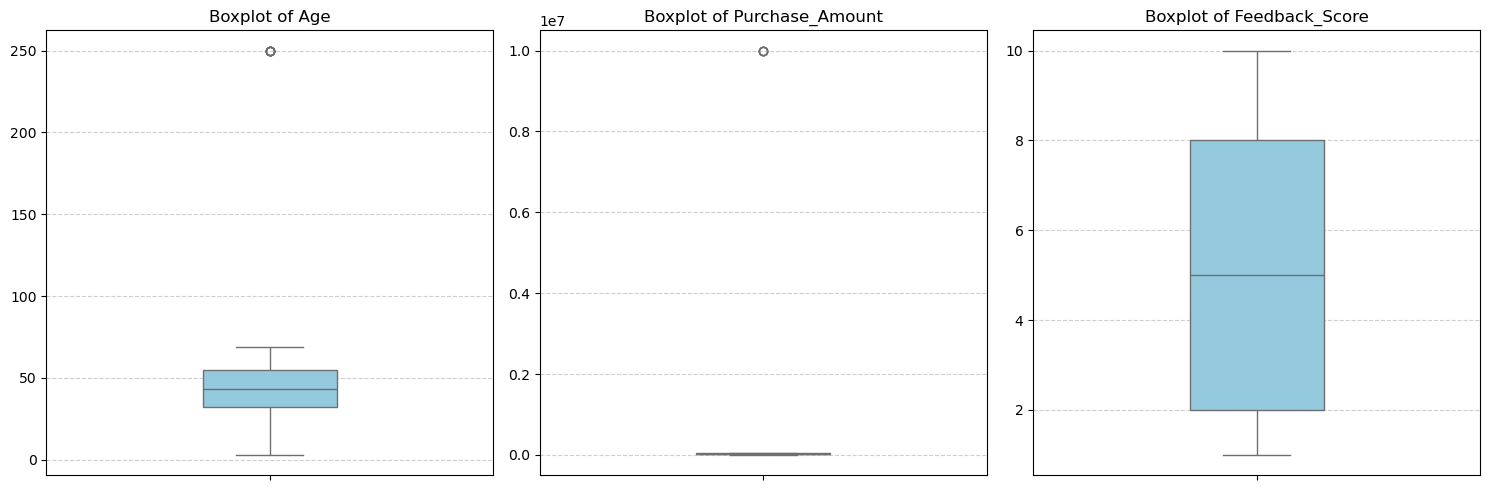

In [60]:
cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=data[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [61]:
from scipy import stats

In [62]:
z_scores = np.abs(stats.zscore(data[['Age','Purchase_Amount']]))

In [63]:
data_clean = data[~(z_scores>3).any(axis = 1)]

In [64]:
data_clean

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,male,52,KOLKATA,2025-06-26,2025-05-17,26944.000000,1.0,peckvictoria@example.com,2131107701,INDIA
1,CUST5957,Jason Thomas,male,51,KOLKATA,2021-02-17,2025-07-22,44152.000000,2.0,owensanthony@example.com,1080761560,INDIA
2,CUST3754,Brittney Martinez,female,62,HYDERABAD,2023-11-05,2024-12-08,31745.000000,2.0,tara39@example.org,8981006345,INDIA
3,CUST2934,Brenda Pierce,female,40,HYDERABAD,2022-03-13,2025-10-02,39674.000000,1.0,berrynancy@example.org,8228064204,INDIA
4,CUST5683,Matthew Carroll,female,41,CHENNAI,2024-04-05,2024-12-15,29536.982788,8.0,denise84@example.org,2665569480,INDIA
...,...,...,...,...,...,...,...,...,...,...,...,...
10193,CUST6352,Isaiah Terry,female,26,KOLKATA,2023-03-04,2025-06-30,43655.000000,6.0,lopezleonard@example.net,7694723210,INDIA
10194,CUST6146,Cody Thompson,female,40,KOLKATA,2024-08-21,2024-10-26,35101.000000,1.0,mitchellrivera@example.net,6380823112,INDIA
10195,CUST10767,Robert Lewis,female,35,DELHI,2020-12-08,2025-01-25,24167.000000,9.0,barrycrane@example.net,5004696571,INDIA
10197,CUST6315,Joshua Martinez,male,25,HYDERABAD,2022-02-15,2025-01-11,43832.000000,2.0,kelli74@example.org,8147428496,INDIA


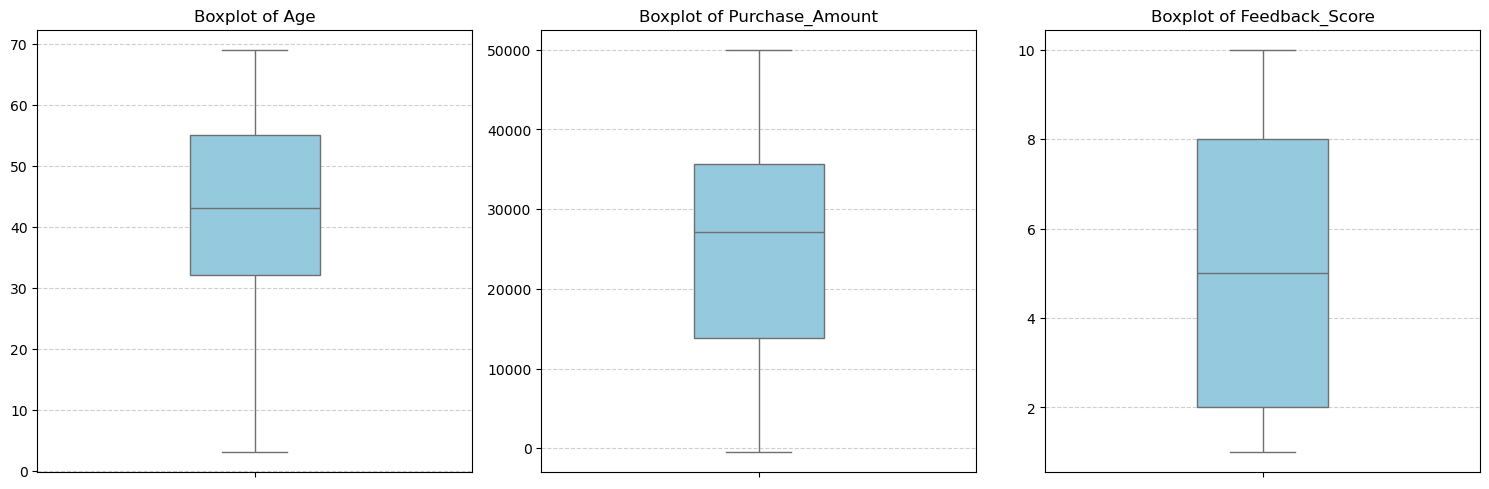

In [65]:
cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=data_clean[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [66]:
data_clean.to_csv('messy_clean_data', index= False)